# 02 — Sample size, power curve, sensitivity

**Stage 4.** Required sample size computed from the pre-registered
parameters: H₁ two-sided, α = 0.05, power = 0.80, MDE = +0.5 p.p.,
baseline (control) conversion p₀ = 0.0179.


## 1. Required sample size (sample size)

Closed-form per-group n for a two-sided two-proportion z-test:
$n = \left(\frac{z_{1-\alpha/2}\sqrt{2\bar p(1-\bar p)} +
z_{1-\beta}\sqrt{p_0(1-p_0)+p_1(1-p_1)}}{p_1-p_0}\right)^2$

Because the data are heavily imbalanced (96/4), the binding
constraint is the *smaller* group: psa (23,524 users). If required n
≤ 23,524 the experiment is adequately powered.


In [1]:
import sys, pathlib
root = pathlib.Path.cwd()
while root != root.parent and not (root / 'data' / 'marketing_AB.csv').exists():
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from src.inference import sample_size_proportions, power_curve, power_for_proportions, cohens_h
P0, MDE, ALPHA, POWER = 0.0179, 0.005, 0.05, 0.80
PSA_N, AD_N = 23_524, 564_577
n_req = sample_size_proportions(P0, MDE)
print(f'required n per group: {n_req:,}')
print(f'psa (binding) group:  {PSA_N:,}; ad group: {AD_N:,}')
print(f'adequately powered?    {n_req <= PSA_N}')
print(f'achieved power at psa n: {power_for_proportions(P0, P0+MDE, PSA_N):.3f}')
print(f"Cohen's h for MDE={MDE}: {cohens_h(P0+MDE, P0):.4f} (small effect)")

required n per group: 12,547
psa (binding) group:  23,524; ad group: 564,577
adequately powered?    True
achieved power at psa n: 0.970
Cohen's h for MDE=0.005: 0.0354 (small effect)


## 2. Power curve (power curve): how power grows with n

Answers: *how much data buys how much power?* The vertical lines
mark the required n (80%) and the actual psa-group size (≈97%).


(0.0, 1.02)

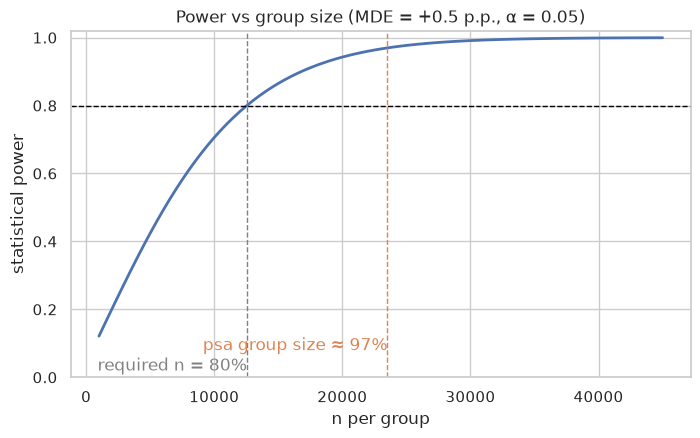

In [2]:
grid = np.arange(1_000, 45_001, 500)
powers = power_curve(P0, P0 + MDE, grid)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(grid, powers, lw=2, color='#4C72B0')
ax.axhline(0.8, ls='--', color='black', lw=1)
ax.axvline(n_req, ls='--', color='gray', lw=1)
ax.axvline(PSA_N, ls='--', color='#DD8452', lw=1)
ax.annotate('required n = 80%', xy=(n_req, 0.02), ha='right', color='gray')
ax.annotate('psa group size ≈ 97%', xy=(PSA_N, 0.08), ha='right', color='#DD8452')
ax.set_title('Power vs group size (MDE = +0.5 p.p., α = 0.05)')
ax.set_xlabel('n per group'); ax.set_ylabel('statistical power')
ax.set_ylim(0, 1.02)

## 3. Sensitivity to MDE (sensitivity analysis)

Answers: *how much more data do we need to catch a smaller effect?*
The orange line is the psa-group ceiling: any MDE whose required n
sits above it is **not detectable** with this data.


Text(0, 0.5, 'n per group (log scale)')

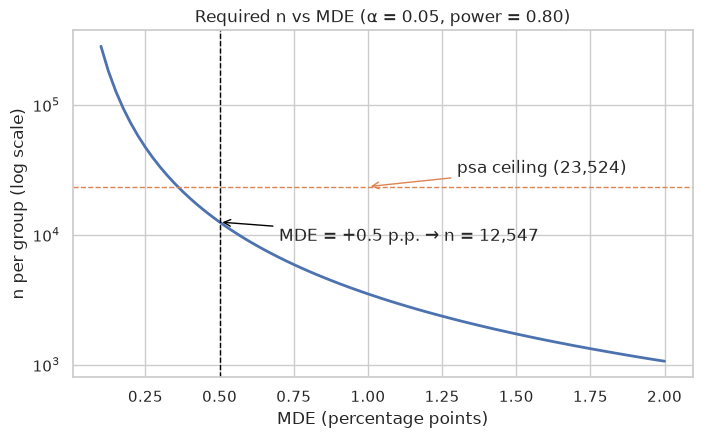

In [3]:
mdes = np.arange(0.001, 0.0201, 0.00025)
ns = np.array([sample_size_proportions(P0, m) for m in mdes])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(mdes * 100, ns, lw=2, color='#4C72B0')
ax.axhline(PSA_N, ls='--', color='#DD8452', lw=1)
ax.axvline(0.5, ls='--', color='black', lw=1)
ax.annotate('MDE = +0.5 p.p. → n = 12,547', xy=(0.5, n_req), xytext=(0.7, 9000), arrowprops=dict(arrowstyle='->', color='black'))
ax.annotate('psa ceiling (23,524)', xy=(1.0, PSA_N), xytext=(1.3, 30000), arrowprops=dict(arrowstyle='->', color='#DD8452'))
ax.set_title('Required n vs MDE (α = 0.05, power = 0.80)')
ax.set_xlabel('MDE (percentage points)'); ax.set_ylabel('n per group (log scale)')

## 4. Stage conclusion

- Required n = **12,547 per group** < psa 23,524 → the experiment is
  adequately powered for MDE +0.5 p.p. at 80%; actual power on the
  binding group ≈ 0.97.
- Sensitivity shows the limits: catching +0.1 p.p. needs ~283K per
  group (infeasible with psa = 23.5K), catching +1 p.p. needs only
  3.5K. The observed uplift (~0.77 p.p.) is comfortably within
  resolvable range — but *resolvability* is not *business value*,
  that decision is practical significance (Stage 6).
